# DATA STRUCTURE 1 FIGURE 

In [1]:
from pynwb import NWBHDF5IO
import pandas as pd 
import matplotlib.pyplot as plt 
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np 
import os
from scipy.stats import pearsonr
from scipy.stats import gaussian_kde

# Set working directory to test this out locally 
os.chdir('/Users/nicole.burke/OneDrive - Child Mind Institute/02_Projects/06_rockland_sample/01_rockland_descriptor_paper/complied_server_data')
print(os.getcwd())

### Custom functions for script 
def descr_stats(df, column_name):
    stats = df[column_name].agg(
        mean='mean',
        min='min',
        max='max',
        std='std'
    )
    print(f"Summary stats for column: {column_name}")
    print(stats)

    return stats

/Users/nicole.burke/Library/CloudStorage/OneDrive-ChildMindInstitute/02_Projects/06_rockland_sample/01_rockland_descriptor_paper/complied_server_data


## The *Present*

In [2]:
#### Read in data 
present_df = pd.read_csv('present_ds1_df.csv')
present_df = present_df.iloc[:, 1:]
print(present_df.head())
print(present_df.shape)

   x_corr_pixels  y_corr_pixels     times      subjectID
0          564.2          631.6 -1.122725  sub-A00010201
1          564.3          630.9 -1.117170  sub-A00010201
2          564.5          629.8 -1.111614  sub-A00010201
3          564.7          628.0 -1.106058  sub-A00010201
4          564.3          628.4 -1.100503  sub-A00010201
(7500629, 4)


In [3]:
### descriptive stats 
present_number_subjects = len(present_df['subjectID'].unique())
print(f"Number of subjects in PRESENT: {present_number_subjects}")

xx = descr_stats(present_df, 'x_corr_pixels')
print("*"*10)
yy = descr_stats(present_df, 'y_corr_pixels')

Number of subjects in PRESENT: 192
Summary stats for column: x_corr_pixels
mean     653.117197
min    -3160.400000
max     3147.400000
std       82.660693
Name: x_corr_pixels, dtype: float64
**********
Summary stats for column: y_corr_pixels
mean     410.297653
min    -3263.300000
max     3275.800000
std      127.219302
Name: y_corr_pixels, dtype: float64


In [4]:
records = []

for subj, grp in present_df.groupby("subjectID"):
    grp = grp.sort_values("times").reset_index(drop=True)
    # print("group variable:", grp)

    times = grp["times"].values
    x     = grp["x_corr_pixels"].values
    y     = grp["y_corr_pixels"].values

    # ── Sample rate
    diffs       = np.diff(times)
    median_dt   = np.median(diffs)
    sample_rate = 1.0 / median_dt if median_dt > 0 else np.nan

    # ── Data loss: NaN + zeros (common tracker placeholder)
    n_total     = len(grp)
    n_nan       = grp[["x_corr_pixels", "y_corr_pixels"]].isna().any(axis=1).sum()
    n_zero      = ((x == 0) & (y == 0)).sum()
    n_missing   = n_nan + n_zero
    pct_missing = n_missing / n_total * 100

    # ── Coordinate ranges
    x_min, x_max = np.nanmin(x), np.nanmax(x)
    y_min, y_max = np.nanmin(y), np.nanmax(y)

    # ── Gaze velocity (px/s) — robust noise indicator
    dx       = np.diff(x)
    dy       = np.diff(y)
    dist     = np.sqrt(dx**2 + dy**2)
    velocity = dist / diffs                        # px/s
    vel_median = np.nanmedian(velocity)
    vel_sd     = np.nanstd(velocity)
    vel_p95    = np.nanpercentile(velocity, 95)

    # ── Timestamp regularity (jitter)
    dt_sd    = np.std(diffs) * 1000                # ms jitter

    records.append({
        "subjectID"     : subj,
        "n_samples"     : n_total,
        "sample_rate_hz": round(sample_rate, 1),
        "dt_jitter_ms"  : round(dt_sd, 3),
        "pct_missing"   : round(pct_missing, 2),
        "x_min"         : round(x_min, 1),
        "x_max"         : round(x_max, 1),
        "y_min"         : round(y_min, 1),
        "y_max"         : round(y_max, 1),
        "x_range"       : round(x_max - x_min, 1),
        "y_range"       : round(y_max - y_min, 1),
        "vel_median_pxs": round(vel_median, 1),
        "vel_sd_pxs"    : round(vel_sd, 1),
        "vel_p95_pxs"   : round(vel_p95, 1),
    })

audit = pd.DataFrame(records).sort_values("x_min").reset_index(drop=True)

# print("=" * 70)
# print("PER-SUBJECT AUDIT SUMMARY: PRESENT data_structure_1")
# print("=" * 70)
# print(audit.to_string(index=False))
sampling_rate = descr_stats(audit, 'sample_rate_hz')
x_min = descr_stats(audit, 'x_min')
y_min = descr_stats(audit, 'y_min')
unique_hz = audit['sample_rate_hz'].unique().tolist()
print(f"unique sampling rate in sample: {unique_hz}")

Summary stats for column: sample_rate_hz
mean    178.313542
min      55.500000
max     180.000000
std      13.167174
Name: sample_rate_hz, dtype: float64
Summary stats for column: x_min
mean      82.620833
min    -3160.400000
max      622.100000
std      430.811558
Name: x_min, dtype: float64
Summary stats for column: y_min
mean    -182.952083
min    -3263.300000
max      814.700000
std      791.559343
Name: y_min, dtype: float64
unique sampling rate in sample: [180.0, 177.8, 179.6, 179.5, 126.1, 165.6, 179.8, 57.4, 176.7, 55.5, 179.4]


### The *Present* FILTERED

In [ ]:
### present
# x
present_mean_x = present_df['x_corr_pixels'].mean()
present_sd_x = present_df['x_corr_pixels'].std()
print(f"present x_corr mean: {present_mean_x} and std: {present_sd_x}")
present_upper_x = present_mean_x + (present_sd_x*2.5)
present_lower_x = present_mean_x - (present_sd_x*2.5)
print(f"present x_corr upper: {present_upper_x} and lower: {present_lower_x}")
print(f"present x_corr min x: {present_df['x_corr_pixels'].min()} and max x: {present_df['x_corr_pixels'].max()}")
print(f"present number of samples: {len(present_df)}")

# filter out oultiers 
present_df_filtered = present_df[
    (present_df['x_corr_pixels'] <= present_upper_x) &
    (present_df['x_corr_pixels'] >= present_lower_x)
]
print(f"Filter present mean x: {present_df_filtered['x_corr_pixels'].mean()}, x_min: {present_df_filtered['x_corr_pixels'].min()}, x_max: {present_df_filtered['x_corr_pixels'].max()}")
print(f"Filter present number of samples lost: {len(present_df)-len(present_df_filtered)}")

print("*"*50)

# y 
present_mean_y = present_df['y_corr_pixels'].mean()
present_sd_y = present_df['y_corr_pixels'].std()
print(f"present y_corr mean: {present_mean_y} and std: {present_sd_y}")
present_upper_y = present_mean_y + (present_sd_y*2.5)
present_lower_y = present_mean_y - (present_sd_y*2.5)
print(f"present y_corr upper: {present_upper_y} and lower: {present_lower_y}")
print(f"present y_corr min y: {present_df['y_corr_pixels'].min()} and max y: {present_df['y_corr_pixels'].max()}")

# filter out outliers 
present_df_filtered = present_df_filtered[
    (present_df_filtered['y_corr_pixels'] <= present_upper_y) &
    (present_df_filtered['y_corr_pixels'] >= present_lower_y)
]
print(f"Filtered present mean y: {present_df_filtered['y_corr_pixels'].mean()}, y_min: {present_df_filtered['y_corr_pixels'].min()}, y_max: {present_df_filtered['y_corr_pixels'].max()}")
print(f"Filter present number of samples lost: {len(present_df)-len(present_df_filtered)}")
print(f"Filter present number of subjects: {len(present_df['subjectID'].unique())}")

### The *Present* STANDARIZED

In [ ]:
# present 
present_df_standard = present_df_filtered
x_min_present = present_df_filtered['x_corr_pixels'].min()
x_max_present = present_df_filtered['x_corr_pixels'].max()
present_df_standard['x_norm'] = (present_df_standard['x_corr_pixels'] - x_min_present) / (x_max_present - x_min_present)
x_norm = descr_stats(present_df_standard, 'x_norm')

print("*"*50)

y_min_present = present_df_filtered['y_corr_pixels'].min()
y_max_present = present_df_filtered['y_corr_pixels'].max()
present_df_standard['y_norm'] = (present_df_standard['y_corr_pixels'] - y_min_present) / (y_max_present - y_min_present)
y_norm = descr_stats(present_df_standard, 'y_norm')

### The *Present* PLOT

In [ ]:
plt.figure(figsize=(8, 4))

plt.hexbin(
    present_df_standard['times'],
    present_df_standard['x_norm'],
    gridsize=100,
)

plt.colorbar(label='Density')
plt.xlabel('Time')
plt.ylabel('X position (pixels)')
plt.title('The Present: Fixation X over Time')

plt.show()

In [ ]:
plt.figure(figsize=(8, 4))

plt.hexbin(
    present_df_standard['times'],
    present_df_standard['y_norm'],
    gridsize=100,
)

plt.colorbar(label='Density')
plt.xlabel('Time')
plt.ylabel('Y position (pixels)')
plt.title('The Present: Fixation Y over Time')

plt.show()

## *Sherlock*

In [ ]:
### read in data 
sherlock_df = pd.read_csv("sherlock_ds1_df.csv")
sherlock_df = sherlock_df.iloc[:, 1:]
print(sherlock_df.head())
print(sherlock_df.shape)

In [7]:
### descriptive stats 
sherlock_number_subjects = len(sherlock_df['subjectID'].unique())
print(f"Number of subjects in SHERLOCK: {sherlock_number_subjects}")

xx = descr_stats(sherlock_df, 'x_corr_pixels')
print("*"*10)
yy = descr_stats(sherlock_df, 'y_corr_pixels')

Number of subjects in SHERLOCK: 192
Summary stats for column: x_corr_pixels
mean     631.713533
min    -3213.200000
max     3210.400000
std      128.220123
Name: x_corr_pixels, dtype: float64
**********
Summary stats for column: y_corr_pixels
mean     400.642350
min    -3276.700000
max     3276.700000
std      215.704618
Name: y_corr_pixels, dtype: float64


In [8]:
records = []

for subj, grp in sherlock_df.groupby("subjectID"):
    grp = grp.sort_values("times").reset_index(drop=True)
    # print("group variable:", grp)

    times = grp["times"].values
    x     = grp["x_corr_pixels"].values
    y     = grp["y_corr_pixels"].values

    # ── Sample rate
    diffs       = np.diff(times)
    median_dt   = np.median(diffs)
    sample_rate = 1.0 / median_dt if median_dt > 0 else np.nan

    # ── Data loss: NaN + zeros (common tracker placeholder)
    n_total     = len(grp)
    n_nan       = grp[["x_corr_pixels", "y_corr_pixels"]].isna().any(axis=1).sum()
    n_zero      = ((x == 0) & (y == 0)).sum()
    n_missing   = n_nan + n_zero
    pct_missing = n_missing / n_total * 100

    # ── Coordinate ranges
    x_min, x_max = np.nanmin(x), np.nanmax(x)
    y_min, y_max = np.nanmin(y), np.nanmax(y)

    # ── Gaze velocity (px/s) — robust noise indicator
    dx       = np.diff(x)
    dy       = np.diff(y)
    dist     = np.sqrt(dx**2 + dy**2)
    velocity = dist / diffs                        # px/s
    vel_median = np.nanmedian(velocity)
    vel_sd     = np.nanstd(velocity)
    vel_p95    = np.nanpercentile(velocity, 95)

    # ── Timestamp regularity (jitter)
    dt_sd    = np.std(diffs) * 1000                # ms jitter

    records.append({
        "subjectID"     : subj,
        "n_samples"     : n_total,
        "sample_rate_hz": round(sample_rate, 1),
        "dt_jitter_ms"  : round(dt_sd, 3),
        "pct_missing"   : round(pct_missing, 2),
        "x_min"         : round(x_min, 1),
        "x_max"         : round(x_max, 1),
        "y_min"         : round(y_min, 1),
        "y_max"         : round(y_max, 1),
        "x_range"       : round(x_max - x_min, 1),
        "y_range"       : round(y_max - y_min, 1),
        "vel_median_pxs": round(vel_median, 1),
        "vel_sd_pxs"    : round(vel_sd, 1),
        "vel_p95_pxs"   : round(vel_p95, 1),
    })

audit = pd.DataFrame(records).sort_values("x_min").reset_index(drop=True)

# print("=" * 70)
# print("PER-SUBJECT AUDIT SUMMARY: SHERLOCK data_structure_1")
# print("=" * 70)
# print(audit.to_string(index=False))
sampling_rate = descr_stats(audit, 'sample_rate_hz')
x_min = descr_stats(audit, 'x_min')
y_min = descr_stats(audit, 'y_min')
unique_hz = audit['sample_rate_hz'].unique().tolist()
print(f"unique sampling rate in sample: {unique_hz}")

Summary stats for column: sample_rate_hz
mean    176.897396
min      55.700000
max     180.000000
std      14.797224
Name: sample_rate_hz, dtype: float64
Summary stats for column: x_min
mean    -153.439583
min    -3213.200000
max      531.700000
std      490.474895
Name: x_min, dtype: float64
Summary stats for column: y_min
mean    -689.075521
min    -3276.700000
max      556.000000
std     1206.663623
Name: y_min, dtype: float64
unique sampling rate in sample: [179.3, 180.0, 122.7, 156.3, 179.0, 147.4, 145.8, 179.6, 155.8, 150.0, 151.1, 151.6, 56.9, 176.7, 55.7, 124.7, 151.9, 179.8]


### *Sherlock* FILTERED

In [9]:
### sherlock
# x
sherlock_mean_x = sherlock_df['x_corr_pixels'].mean()
sherlock_sd_x = sherlock_df['x_corr_pixels'].std()
print(f"sherlock x_corr mean: {sherlock_mean_x} and std: {sherlock_sd_x}")
sherlock_upper_x = sherlock_mean_x + (sherlock_sd_x*2.5)
sherlock_lower_x = sherlock_mean_x - (sherlock_sd_x*2.5)
print(f"sherlock x_corr upper: {sherlock_upper_x} and lower: {sherlock_lower_x}")
print(f"sherlock x_corr min x: {sherlock_df['x_corr_pixels'].min()} and max x: {sherlock_df['x_corr_pixels'].max()}")
print(f"sherlock number of samples: {len(sherlock_df)}")

# filter out oultiers 
sherlock_df_filtered = sherlock_df[
    (sherlock_df['x_corr_pixels'] <= sherlock_upper_x) &
    (sherlock_df['x_corr_pixels'] >= sherlock_lower_x)
]
print(f"Filter sherlock mean x: {sherlock_df_filtered['x_corr_pixels'].mean()}, x_min: {sherlock_df_filtered['x_corr_pixels'].min()}, x_max: {sherlock_df_filtered['x_corr_pixels'].max()}")
print(f"Filter sherlock number of samples lost: {len(sherlock_df)-len(sherlock_df_filtered)}")

print("*"*50)

# y 
sherlock_mean_y = sherlock_df['y_corr_pixels'].mean()
sherlock_sd_y = sherlock_df['y_corr_pixels'].std()
print(f"sherlock y_corr mean: {sherlock_mean_y} and std: {sherlock_sd_y}")
sherlock_upper_y = sherlock_mean_y + (sherlock_sd_y*2.5)
sherlock_lower_y = sherlock_mean_y - (sherlock_sd_y*2.5)
print(f"sherlock y_corr upper: {sherlock_upper_y} and lower: {sherlock_lower_y}")
print(f"sherlock y_corr min y: {sherlock_df['y_corr_pixels'].min()} and max y: {sherlock_df['y_corr_pixels'].max()}")

# filter out outliers 
sherlock_df_filtered = sherlock_df_filtered[
    (sherlock_df_filtered['y_corr_pixels'] <= sherlock_upper_y) &
    (sherlock_df_filtered['y_corr_pixels'] >= sherlock_lower_y)
]
print(f"Filtered sherlock mean y: {sherlock_df_filtered['y_corr_pixels'].mean()}, y_min: {sherlock_df_filtered['y_corr_pixels'].min()}, y_max: {sherlock_df_filtered['y_corr_pixels'].max()}")
print(f"Filter sherlock number of samples lost: {len(sherlock_df)-len(sherlock_df_filtered)}")
print(f"Filter sherlock number of subjects: {len(sherlock_df['subjectID'].unique())}")

sherlock x_corr mean: 631.713533414479 and std: 128.22012334351132
sherlock x_corr upper: 952.2638417732574 and lower: 311.1632250557007
sherlock x_corr min x: -3213.2 and max x: 3210.4
sherlock number of samples: 20762676
Filter sherlock mean x: 640.4973818277572, x_min: 311.2, x_max: 952.2
Filter sherlock number of samples lost: 536543
**************************************************
sherlock y_corr mean: 400.64234996972453 and std: 215.7046180931074
sherlock y_corr upper: 939.903895202493 and lower: -138.619195263044
sherlock y_corr min y: -3276.7 and max y: 3276.7
Filtered sherlock mean y: 395.54509381764166, y_min: -138.6, y_max: 939.9
Filter sherlock number of samples lost: 814722
Filter sherlock number of subjects: 192


### *Sherlock* STANDARIZED

In [10]:
# sherlock 
sherlock_df_standard = sherlock_df_filtered
x_min_sherlock = sherlock_df_filtered['x_corr_pixels'].min()
x_max_sherlock = sherlock_df_filtered['x_corr_pixels'].max()
sherlock_df_standard['x_norm'] = (sherlock_df_standard['x_corr_pixels'] - x_min_sherlock) / (x_max_sherlock - x_min_sherlock)
x_norm = descr_stats(sherlock_df_standard, 'x_norm')

print("*"*50)

y_min_sherlock = sherlock_df_filtered['y_corr_pixels'].min()
y_max_sherlock = sherlock_df_filtered['y_corr_pixels'].max()
sherlock_df_standard['y_norm'] = (sherlock_df_standard['y_corr_pixels'] - y_min_sherlock) / (y_max_sherlock - y_min_sherlock)
y_norm = descr_stats(sherlock_df_standard, 'y_norm')

Summary stats for column: x_norm
mean    0.516158
min     0.000000
max     1.000000
std     0.128598
Name: x_norm, dtype: float64
**************************************************
Summary stats for column: y_norm
mean    0.495267
min     0.000000
max     1.000000
std     0.109302
Name: y_norm, dtype: float64


### *Sherlock* PLOT

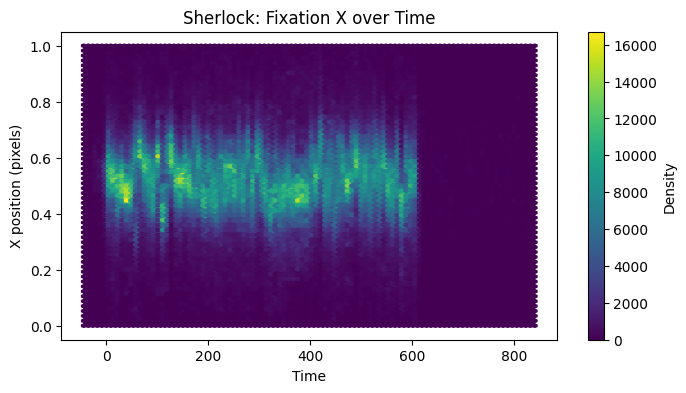

In [11]:
plt.figure(figsize=(8, 4))

plt.hexbin(
    sherlock_df_standard['times'],
    sherlock_df_standard['x_norm'],
    gridsize=100,
)

plt.colorbar(label='Density')
plt.xlabel('Time')
plt.ylabel('X position (pixels)')
plt.title('Sherlock: Fixation X over Time')

plt.show()

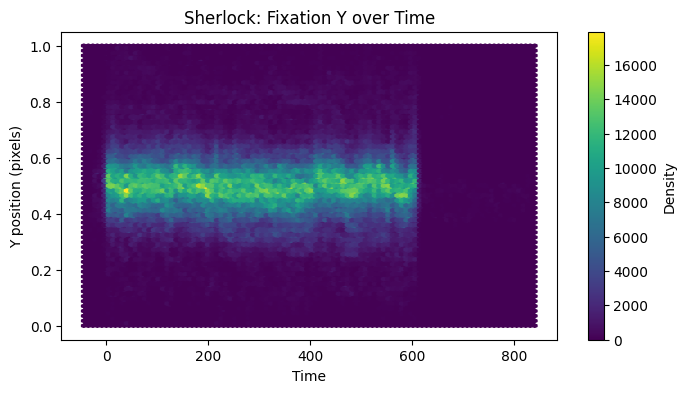

In [12]:
plt.figure(figsize=(8, 4))

plt.hexbin(
    sherlock_df_standard['times'],
    sherlock_df_standard['y_norm'],
    gridsize=100,
)

plt.colorbar(label='Density')
plt.xlabel('Time')
plt.ylabel('Y position (pixels)')
plt.title('Sherlock: Fixation Y over Time')

plt.show()